<a href="https://colab.research.google.com/github/LailaBulh/Procesamiento_Lenguaje_Natural/blob/main/Proyecto_Final_263166_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto Final**

**Nombre:** Laila Montserrat Bulhosen Ramos **Matrícula**: 263166

**Docente:** Dr. Rogelio Florencia Juarez

**Materia:** Procesamiento de Lenguaje Natural



**Link Github:** [Proyecto_Final_263166](https://github.com/LailaBulh/Procesamiento_Lenguaje_Natural/blob/main/Proyecto_Final_263166.ipynb)

**Fecha:** Mayor 2026


### **Carga de dataset**


In [1]:
### Drive connection

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

In [3]:
dataset = pd.read_csv('/content/drive/MyDrive/Procesamiento Lenguaje Natural/Dataset.csv')

In [ ]:
#dataset = pd.read_csv('Dataset.csv')

In [4]:
display(dataset.head(5))

,phrase,prompt
0,When I remember her I feel down,Emotional pain
1,When I carry heavy things I feel like breaking...,Hair falling out
2,there is too much pain when i move my arm,Heart hurts
3,My son had his lip pierced and it is swollen a...,Infected wound
4,My muscles in my lower back are aching,Infected wound


### **EDA**

**Descripción**

In [ ]:
print('Tamaño del dataset:', dataset.shape)

print('\nDescibe del dataset:')
dataset.describe()


Tamaño del dataset: (6661, 2)

Descibe del dataset:


,phrase,prompt
count,6661,6661
unique,706,25
top,When I stand up too quickly I start to feel di...,Acne
freq,35,328


In [ ]:
print('\nInformación del dataset:\n')
dataset.info()


Información del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6661 entries, 0 to 6660
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   phrase  6661 non-null   object
 1   prompt  6661 non-null   object
dtypes: object(2)
memory usage: 104.2+ KB


**Distribución de clases**

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
### Clases de síntomas en el dataset

clases = dataset['prompt'].value_counts()

df_clases = pd.DataFrame(clases)

print('Las clases encontradas en el dataset son:\n', df_clases)

Las clases encontradas en el dataset son:
                     count
prompt                   
Acne                  328
Shoulder pain         320
Joint pain            318
Infected wound        306
Knee pain             305
Cough                 293
Feeling dizzy         283
Muscle pain           282
Heart hurts           273
Ear ache              270
Hair falling out      264
Head ache             263
Feeling cold          263
Skin issue            262
Stomach ache          261
Back pain             259
Neck pain             251
Internal pain         248
Blurry vision         246
Body feels weak       241
Hard to breath        233
Emotional pain        231
Injury from sports    230
Foot ache             223
Open wound            208


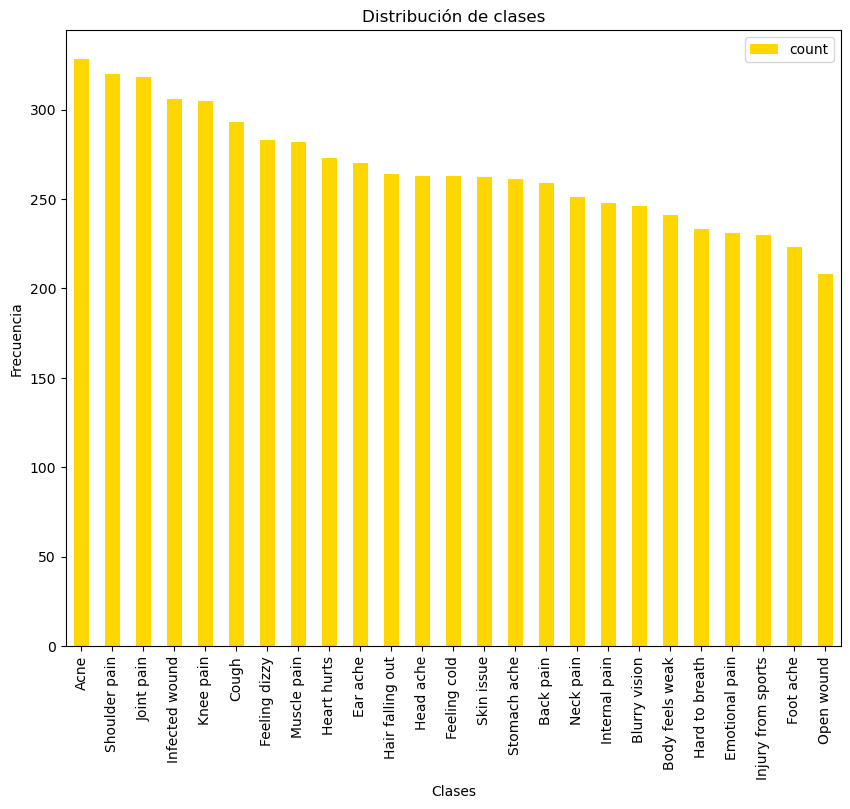

In [ ]:
df_clases.plot(kind = 'bar', figsize = (10,8), color = ['gold'])

plt.title('Distribución de clases')
plt.xlabel('Clases')
#plt.xticks(rotation = 25)
plt.ylabel('Frecuencia')

plt.show()

**Tokenización**

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize


In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/lailabulhusen/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lailabulhusen/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lailabulhusen/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
### Convertir a minúsculas
data_min = dataset['phrase'].str.lower()

display(data_min.head(3))

0                      when i remember her i feel down
1    when i carry heavy things i feel like breaking...
2            there is too much pain when i move my arm
Name: phrase, dtype: object

In [ ]:
### Remover puntuaciones

data_clean = data_min.str.replace(r'[^\w\s]', '', regex=True)

display(data_clean.head(3))

0                      when i remember her i feel down
1    when i carry heavy things i feel like breaking...
2            there is too much pain when i move my arm
Name: phrase, dtype: object

In [ ]:
### Unir frases

all_data = ' '.join(data_clean.tolist())

In [ ]:
### Remover stopwords

stop_words = set(stopwords.words('english'))

all_data_clean = ' '.join([word for word in all_data.split() if word.lower() not in stop_words])

#print(all_data_clean)


In [ ]:
### Tokenizacion

tokens = word_tokenize(all_data_clean)

tokens_unique = pd.Series(tokens).value_counts()

print('Top 10 de tokens más comúnes:\n\n',tokens_unique.head(10))

Top 10 de tokens más comúnes:

 pain        1604
feel        1533
cant         574
like         507
hurts        460
get          409
back         387
im           339
hair         300
shoulder     300
Name: count, dtype: int64


**Nube de palabras**

In [ ]:
from wordcloud import WordCloud


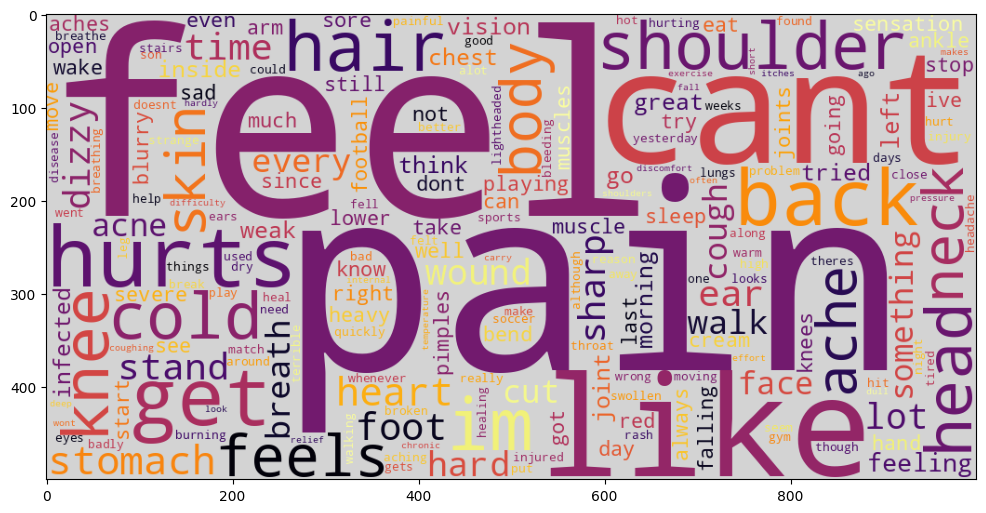

In [ ]:
plt.figure(figsize = (12,10))

worldcloud_im = WordCloud(width = 1000, height = 500, background_color = 'lightgray', collocations = False, colormap = 'inferno').generate_from_frequencies(tokens_unique)

plt.imshow(worldcloud_im)
plt.show()

**Análisis de n-gramas**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
### Crear vectorizador para bigramas y trigramas

vectorizer = CountVectorizer(ngram_range=(2,3))
X = vectorizer.fit_transform(data_clean)

# Convertir a DataFrame con frecuencias
ngrams_freq = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
).sum().sort_values(ascending=False)

print(ngrams_freq.head(20))


in my           1266
pain in          787
pain in my       656
in the           380
on my            358
feel pain        316
feel pain in     250
my head          234
my neck          226
my back          218
my body          218
my shoulder      199
my knee          197
of my            189
my heart         187
my hair          185
there is         185
have pain        184
sharp pain       181
my stomach       173
dtype: int64


### **Entrenamiento de embeddings**

In [ ]:
from gensim.models import Word2Vec
import matplotlib.pyplot as plt


**Doc2Vec**

In [ ]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.decomposition import PCA

In [ ]:
### Tokenizar y etiquetar cada frase
tagged_data = [ TaggedDocument(words=word_tokenize(row.lower())
              ,tags=[str(i)]) for i, row in enumerate(data_clean)
              ]

### Entrenar modelo doc2vec

model = Doc2Vec(
    documents=tagged_data
    ,vector_size=100
    ,window=5          # tamaño del contexto
    ,min_count=1       # ignora palabras con frecuencia menor
    ,epochs=20          # número de iteraciones
)


### Vector del primer documento
vector_doc0 = model.dv['0']
print(vector_doc0[:10])  # primeros 10 valores

### Similitud entre documentos
similar_docs = model.dv.most_similar('0', topn=5)
print(similar_docs)


[ 0.06504696  0.0203933  -0.00564471  0.03413248 -0.01686743 -0.01030432
 -0.07019897  0.08242843 -0.05182976 -0.01385338]
[('2103', 0.9381300806999207), ('3439', 0.9285008311271667), ('2028', 0.9089395403862), ('6154', 0.9079717993736267), ('5453', 0.9020114541053772)]


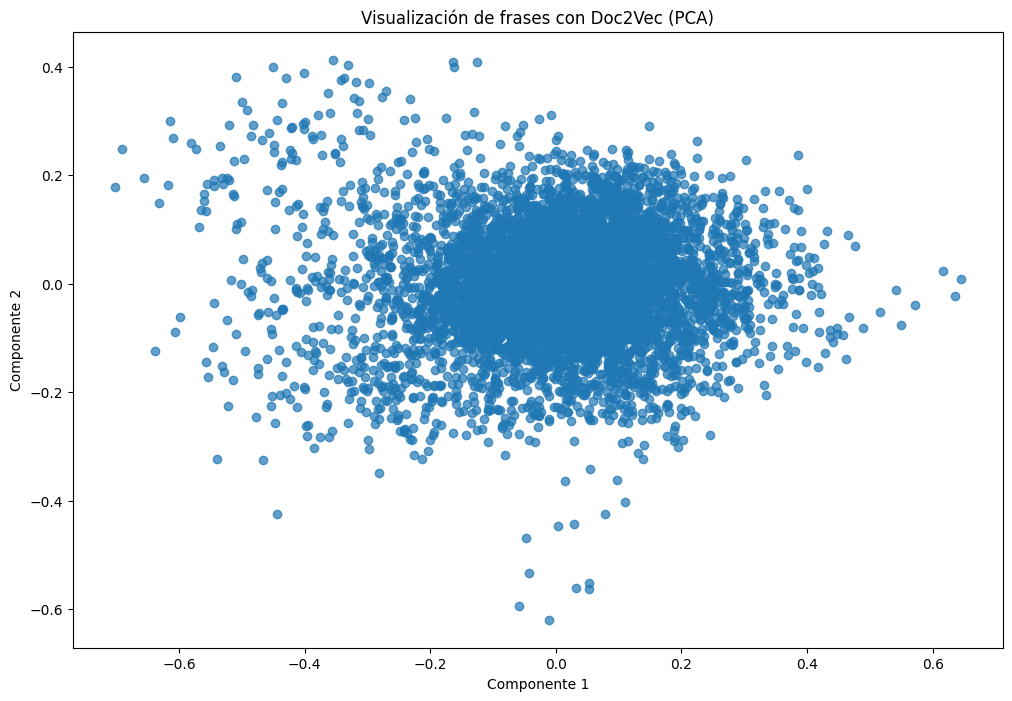

In [ ]:
### Extraer vectores
doc_vectors = [model.dv[str(i)] for i in range(len(data_clean))]

### Reducir a 2 dimensiones
pca = PCA(n_components=2)
doc_vecs_2d = pca.fit_transform(doc_vectors)


plt.figure(figsize=(12,8))
plt.scatter(doc_vecs_2d[:,0], doc_vecs_2d[:,1], alpha=0.7)

plt.title('Visualización de frases con Doc2Vec (PCA)')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.show()


In [ ]:
#print(tagged_data)

In [ ]:
print(data_clean)

0                         when i remember her i feel down
1       when i carry heavy things i feel like breaking...
2               there is too much pain when i move my arm
3       my son had his lip pierced and it is swollen a...
4                  my muscles in my lower back are aching
                              ...                        
6656    i feel a burning sensation in my guts about 2 ...
6657        i have a split on my thumb that will not heal
6658                   i feel a lot of pain in the joints
6659            the area around my heart doesnt feel good
6660                    i complain alot with skin allergy
Name: phrase, Length: 6661, dtype: object


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, f1_score


## Crear embeddings con modelo entrenado


In [ ]:
enunciados_list = data_clean.tolist()
model_emb = SentenceTransformer("paraphrase-MiniLM-L6-v2")
embeddings = model_emb.encode(enunciados_list,show_progress_bar=True)
print(embeddings.shape)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.51k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/209 [00:00<?, ?it/s]

(6661, 384)


In [ ]:
##Preparar variable para entrenar modelos de prediccion

In [ ]:
X = embeddings
y = dataset['prompt'].tolist()

In [ ]:
#entrenar modelos con gridsearch para obtener mejor modelo


#Config SVM
param_grid_svm = {
    "C": [0.01, 0.1, 1, 10]
}

grid_search_svm = GridSearchCV(
    LinearSVC(),
    param_grid_svm,
    cv=10,
    scoring="accuracy",
    n_jobs=-1,
    verbose = 3
)

grid_search_svm.fit(X, y)

print("Mejor SVM:", grid_search_svm.best_score_, grid_search_svm.best_params_)



Fitting 10 folds for each of 4 candidates, totalling 40 fits


/opt/miniconda3/envs/py-LB/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/miniconda3/envs/py-LB/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/miniconda3/envs/py-LB/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/miniconda3/envs/py-LB/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/miniconda3/envs/py-LB/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/miniconda3/envs/py-LB/lib/python3.10/site-packages/sklearn/svm/_base.p

Mejor SVM: 0.9983508245877062 {'C': 1}


In [ ]:
#config RandomForest
param_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(),
    param_rf,
    cv=10,
    scoring="accuracy",
    n_jobs=-1,
    verbose = 3
)

grid_search_rf.fit(X, y)
print("Mejor RF:", grid_search_rf.best_score_, grid_search_rf.best_params_, grid_search_rf.best_estimator_)

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Mejor RF: 0.9983508245877062 {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100} RandomForestClassifier()


In [ ]:


#Config logistic regression
param_grid_lr = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

lrgrid = GridSearchCV(
    LogisticRegression(max_iter=500),
    param_grid_lr,
    cv=10,
    scoring="accuracy",
    n_jobs=-1,
    verbose = 3
)

lrgrid.fit(X, y)

print("Mejor LR:", lrgrid.best_score_, lrgrid.best_params_,lrgrid.best_estimator_)

Fitting 10 folds for each of 4 candidates, totalling 40 fits
Mejor LR: 0.9983508245877062 {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'} LogisticRegression(C=10, max_iter=500)


Mejor LR: 0.9983483483483484 {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Mejor SVM: 0.9983483483483484 {'C': 1}
Mejor RF: 0.9983483483483484 {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

In [ ]:
lr_best = lrgrid.best_estimator_
y_pred_lr = lr_best.predict(X_test)
precision = precision_score(y_test,y_pred_lr,average='macro')
f1 = f1_score(y_test, y_pred_lr, average = 'macro')
print("Precision:: ", precision)
print("f1_score:: ", f1)

Precision::  0.999375
f1_score::  0.9992889997661183


In [ ]:
svm_best = grid_search_svm.best_estimator_
y_pred_svm = svm_best.predict(X_test)
precision = precision_score(y_test,y_pred_svm,average='macro')
f1 = f1_score(y_test, y_pred_svm, average = 'macro')
print("Precision:: ", precision)
print("f1_score:: ", f1)

Precision::  1.0
f1_score::  1.0


In [ ]:
rf_best = grid_search_svm.best_estimator_
y_pred_rf = rf_best.predict(X_test)
precision = precision_score(y_test,y_pred_rf,average='macro')
f1 = f1_score(y_test, y_pred_rf, average = 'macro')
print("Precision:: ", precision)
print("f1_score:: ", f1)

Precision::  1.0
f1_score::  1.0


In [ ]:
print(y_test[0:50])

['Joint pain', 'Infected wound', 'Cough', 'Blurry vision', 'Body feels weak', 'Back pain', 'Infected wound', 'Feeling cold', 'Knee pain', 'Infected wound', 'Back pain', 'Body feels weak', 'Back pain', 'Ear ache', 'Shoulder pain', 'Head ache', 'Knee pain', 'Ear ache', 'Muscle pain', 'Emotional pain', 'Infected wound', 'Ear ache', 'Hair falling out', 'Emotional pain', 'Hard to breath', 'Heart hurts', 'Shoulder pain', 'Feeling dizzy', 'Hard to breath', 'Joint pain', 'Shoulder pain', 'Infected wound', 'Muscle pain', 'Ear ache', 'Skin issue', 'Hard to breath', 'Skin issue', 'Injury from sports', 'Acne', 'Stomach ache', 'Feeling dizzy', 'Stomach ache', 'Skin issue', 'Body feels weak', 'Heart hurts', 'Back pain', 'Skin issue', 'Body feels weak', 'Feeling dizzy', 'Emotional pain']


In [ ]:
print(y_pred_svm[0:50])

['Joint pain' 'Infected wound' 'Cough' 'Blurry vision' 'Body feels weak'
 'Back pain' 'Infected wound' 'Feeling cold' 'Knee pain' 'Infected wound'
 'Back pain' 'Body feels weak' 'Back pain' 'Ear ache' 'Shoulder pain'
 'Head ache' 'Knee pain' 'Ear ache' 'Muscle pain' 'Emotional pain'
 'Infected wound' 'Ear ache' 'Hair falling out' 'Emotional pain'
 'Hard to breath' 'Heart hurts' 'Shoulder pain' 'Feeling dizzy'
 'Hard to breath' 'Joint pain' 'Shoulder pain' 'Infected wound'
 'Muscle pain' 'Ear ache' 'Skin issue' 'Hard to breath' 'Skin issue'
 'Injury from sports' 'Acne' 'Stomach ache' 'Feeling dizzy' 'Stomach ache'
 'Skin issue' 'Body feels weak' 'Heart hurts' 'Back pain' 'Skin issue'
 'Body feels weak' 'Feeling dizzy' 'Emotional pain']
